In [3]:
import numpy as np
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
import seaborn as sns

ictal_adj_sparse = load_npz(
    "/content/drive/MyDrive/Data/adjacency_sparse/graph_ictal_chb01_03_adjacency_sparse.npz"
)
interictal_adj_sparse = load_npz(
    "/content/drive/MyDrive/Data/adjacency_sparse/graph_interictal_chb01_10_adjacency_sparse.npz"
)

In [4]:
ictal_adj_matrix = ictal_adj_sparse.toarray()
interictal_adj_matrix = interictal_adj_sparse.toarray()

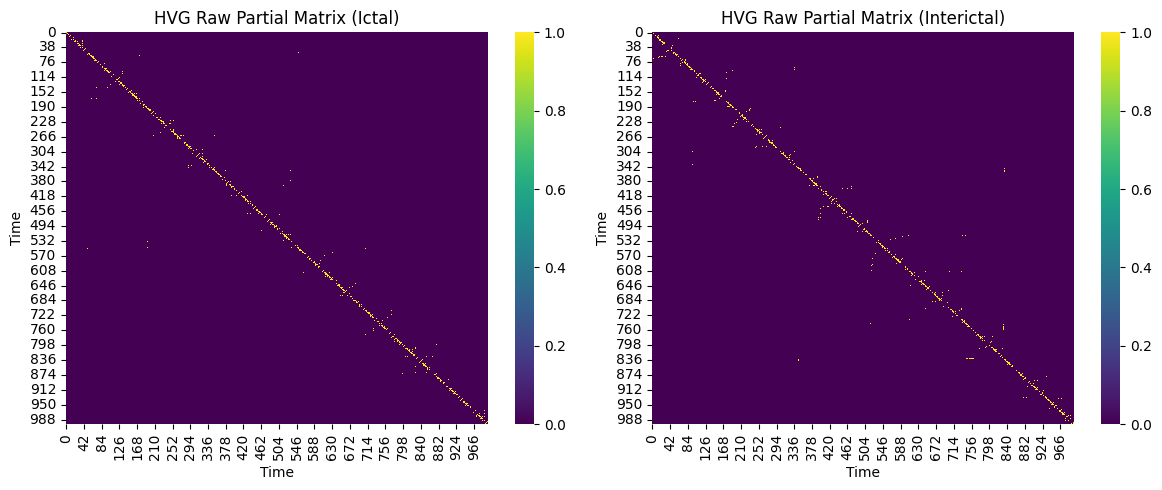

In [5]:
# raw partial matrix
sub_raw_ictal = ictal_adj_matrix[:1000, :1000]
sub_raw_inter = interictal_adj_matrix[:1000, :1000]

# scale fitting
vmin = min(sub_raw_ictal.min(), sub_raw_inter.min())
vmax = max(sub_raw_ictal.max(), sub_raw_inter.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(sub_raw_ictal, cmap="viridis", ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title("HVG Raw Partial Matrix (Ictal)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Time")

sns.heatmap(sub_raw_inter, cmap="viridis", ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title("HVG Raw Partial Matrix (Interictal)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Time")

plt.tight_layout()
plt.show()

In [6]:
def downsample_matrix(mat, factor=20):
    n = mat.shape[0] // factor
    return mat[:n*factor, :n*factor].reshape(n, factor, n, factor).mean(axis=(1,3))

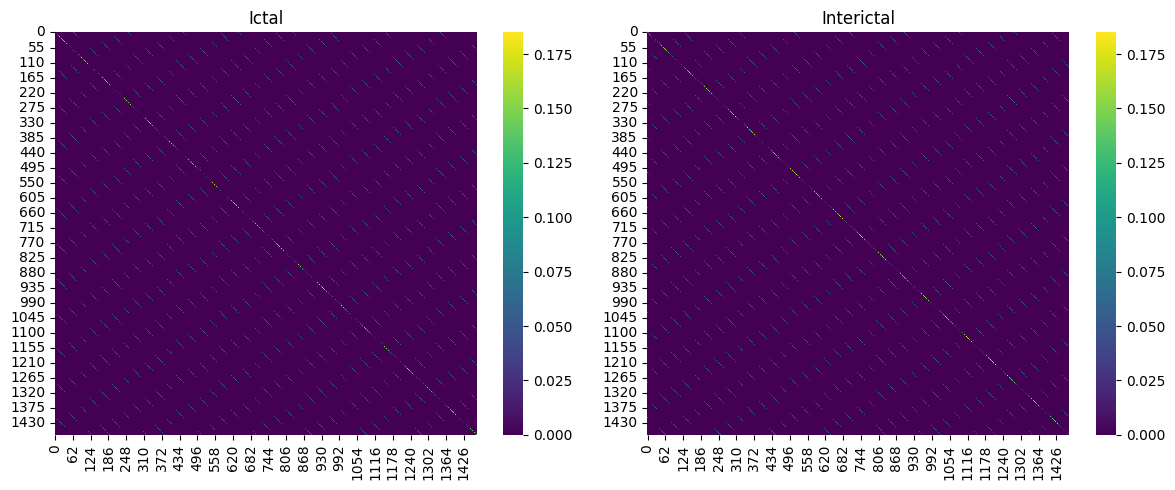

In [56]:
ictal_heatmap = downsample_matrix(ictal_adj_matrix)
interictal_heatmap = downsample_matrix(interictal_adj_matrix)

vmin = min(ictal_heatmap.min(), interictal_heatmap.min())
vmax = max(ictal_heatmap.max(), interictal_heatmap.max())

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(ictal_heatmap, cmap="viridis", ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title("Ictal")

sns.heatmap(interictal_heatmap, cmap="viridis", ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title("Interictal")

plt.tight_layout()
plt.show()

In [7]:
# ICTAL
degree_ictal = ictal_adj_matrix.sum(axis=1)
sorted_idx_ictal = np.argsort(degree_ictal)
sorted_ictal = ictal_adj_matrix[sorted_idx_ictal][:, sorted_idx_ictal]

# INTERICTAL
degree_inter = interictal_adj_matrix.sum(axis=1)
sorted_idx_inter = np.argsort(degree_inter)
sorted_inter = interictal_adj_matrix[sorted_idx_inter][:, sorted_idx_inter]

# downsampling
sub_ictal = sorted_ictal[:300, :300]
sub_inter = sorted_inter[:300, :300]

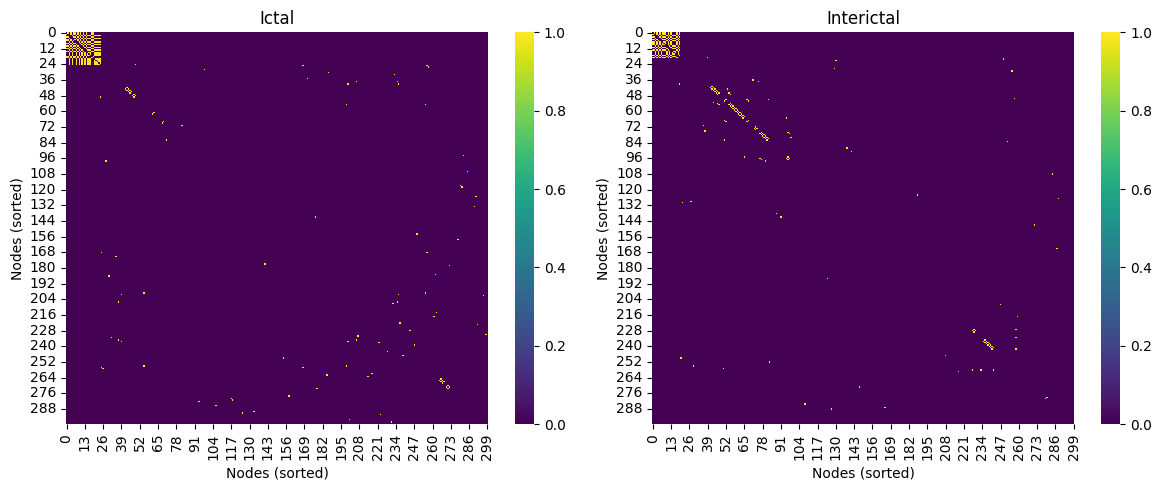

In [8]:
vmin = min(sub_ictal.min(), sub_inter.min())
vmax = max(sub_ictal.max(), sub_inter.max())

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(sub_ictal, cmap="viridis", ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title("Ictal")

sns.heatmap(sub_inter, cmap="viridis", ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title("Interictal")

for ax in axes:
    ax.set_xlabel("Nodes (sorted)")
    ax.set_ylabel("Nodes (sorted)")

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

ictal_edge_list = pd.read_csv("/content/drive/MyDrive/Data/edges/graph_ictal_chb01_03_edges.csv")
interictal_edge_list = pd.read_csv("/content/drive/MyDrive/Data/edges/graph_interictal_chb01_10_edges.csv")

In [10]:
print("ICTAL edge_type counts:")
print(ictal_edge_list["edge_type"].value_counts())

print("\nINTERICTAL edge_type counts:")
print(interictal_edge_list["edge_type"].value_counts())

ICTAL edge_type counts:
edge_type
inter    323840
intra     57974
Name: count, dtype: int64

INTERICTAL edge_type counts:
edge_type
inter    323840
intra     57942
Name: count, dtype: int64


In [11]:
ictal_intra = ictal_edge_list[ictal_edge_list["edge_type"] == "intra"]
ictal_inter = ictal_edge_list[ictal_edge_list["edge_type"] == "inter"]

interictal_intra = interictal_edge_list[interictal_edge_list["edge_type"] == "intra"]
interictal_inter = interictal_edge_list[interictal_edge_list["edge_type"] == "inter"]

In [12]:
from scipy.sparse import coo_matrix

def edge_to_adj(df, n_nodes):
    rows = df["Source"].to_numpy()
    cols = df["Target"].to_numpy()

    if "weight" in df.columns:
        vals = df["weight"].fillna(1).to_numpy()
    else:
        vals = np.ones(len(df), dtype=float)

    mat = coo_matrix((vals, (rows, cols)), shape=(n_nodes, n_nodes))
    mat = mat + mat.T
    return mat.tocsr()

In [13]:
n_nodes = 58880

# Collect all unique node labels from both ictal and interictal edge lists
all_node_labels = pd.concat([
    ictal_edge_list["Source"],
    ictal_edge_list["Target"],
    interictal_edge_list["Source"],
    interictal_edge_list["Target"]
]).unique()

# Create a mapping from node label string to a unique integer ID
node_label_to_int_id = {label: i for i, label in enumerate(all_node_labels)}

# Determine the effective number of nodes based on the unique labels found
# This will be the dimension of the adjacency matrices created from edge lists
effective_n_nodes = len(node_label_to_int_id)

ictal_inter_temp = ictal_inter.copy()
ictal_inter_temp['Source'] = ictal_inter_temp['Source'].map(node_label_to_int_id)
ictal_inter_temp['Target'] = ictal_inter_temp['Target'].map(node_label_to_int_id)

interictal_inter_temp = interictal_inter.copy()
interictal_inter_temp['Source'] = interictal_inter_temp['Source'].map(node_label_to_int_id)
interictal_inter_temp['Target'] = interictal_inter_temp['Target'].map(node_label_to_int_id)

ictal_inter_adj = edge_to_adj(ictal_inter_temp, effective_n_nodes)
interictal_inter_adj = edge_to_adj(interictal_inter_temp, effective_n_nodes)

ictal_intra_temp = ictal_intra.copy()
ictal_intra_temp['Source'] = ictal_intra_temp['Source'].map(node_label_to_int_id)
ictal_intra_temp['Target'] = ictal_intra_temp['Target'].map(node_label_to_int_id)

interictal_intra_temp = interictal_intra.copy()
interictal_intra_temp['Source'] = interictal_intra_temp['Source'].map(node_label_to_int_id)
interictal_intra_temp['Target'] = interictal_intra_temp['Target'].map(node_label_to_int_id)

ictal_intra_adj = edge_to_adj(ictal_intra_temp, effective_n_nodes)
interictal_intra_adj = edge_to_adj(interictal_intra_temp, effective_n_nodes)

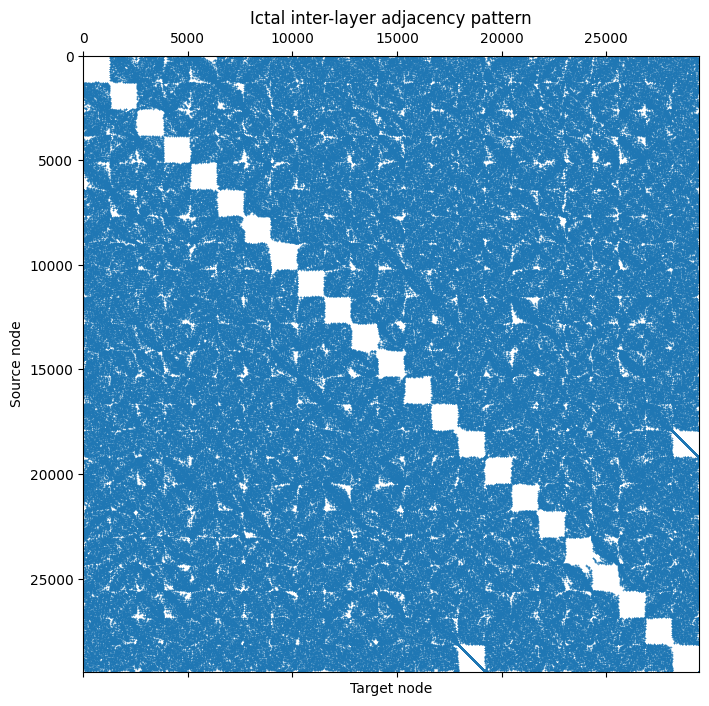

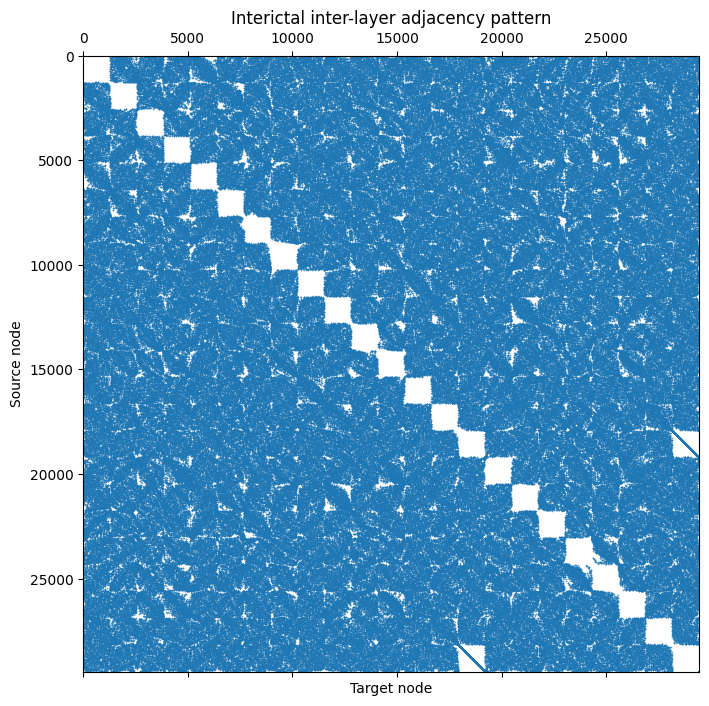

In [16]:
plt.figure(figsize=(8, 8))
plt.spy(ictal_inter_adj, markersize=0.2)
plt.title("Ictal inter-layer adjacency pattern")
plt.xlabel("Target node")
plt.ylabel("Source node")
plt.show()

plt.figure(figsize=(8, 8))
plt.spy(interictal_inter_adj, markersize=0.2)
plt.title("Interictal inter-layer adjacency pattern")
plt.xlabel("Target node")
plt.ylabel("Source node")
plt.show()

In [18]:
def extract_electrode(node_label):
    return str(node_label).rsplit("_t", 1)[0]

def electrode_level_matrix(edge_df):
    df = edge_df.copy()
    df["src_layer"] = df["Source"].apply(extract_electrode)
    df["tgt_layer"] = df["Target"].apply(extract_electrode)

    mat = df.groupby(["src_layer", "tgt_layer"]).size().unstack(fill_value=0)

    layers = sorted(set(mat.index).union(set(mat.columns)))
    mat = mat.reindex(index=layers, columns=layers, fill_value=0)
    return mat

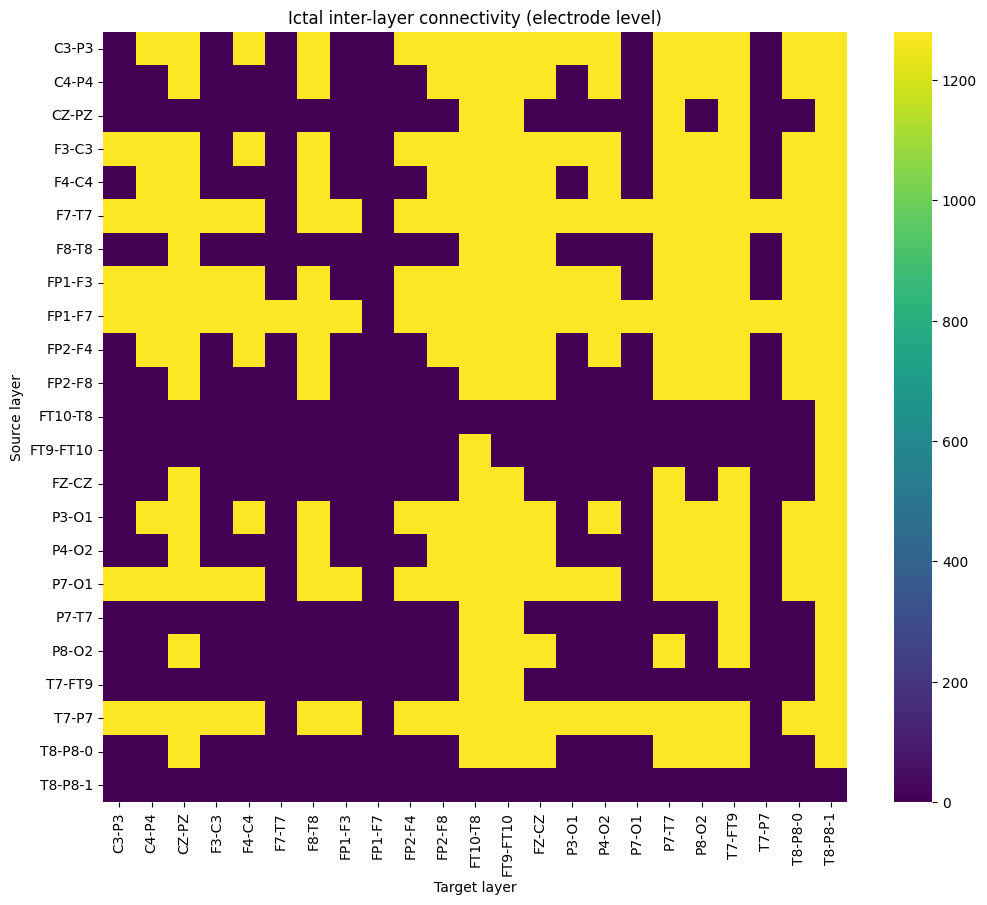

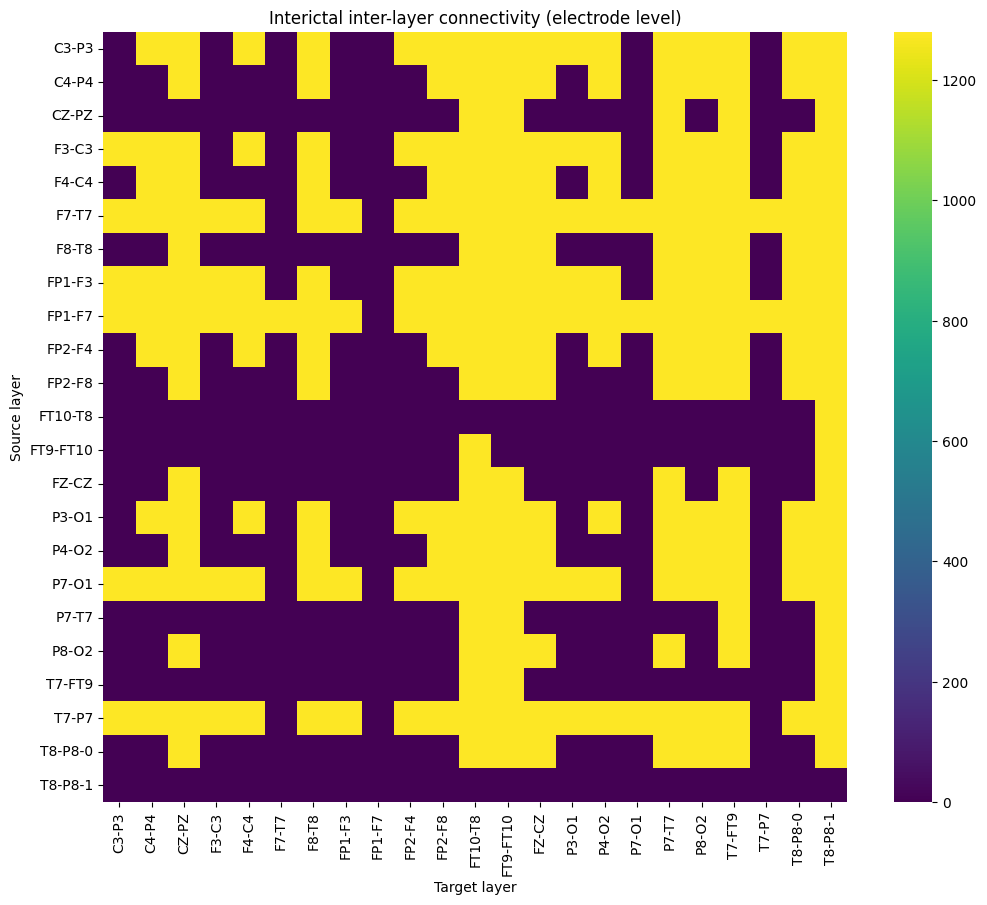

In [19]:
ictal_inter_layer_mat = electrode_level_matrix(ictal_inter)
interictal_inter_layer_mat = electrode_level_matrix(interictal_inter)

plt.figure(figsize=(12, 10))
sns.heatmap(ictal_inter_layer_mat, cmap="viridis")
plt.title("Ictal inter-layer connectivity (electrode level)")
plt.xlabel("Target layer")
plt.ylabel("Source layer")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(interictal_inter_layer_mat, cmap="viridis")
plt.title("Interictal inter-layer connectivity (electrode level)")
plt.xlabel("Target layer")
plt.ylabel("Source layer")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

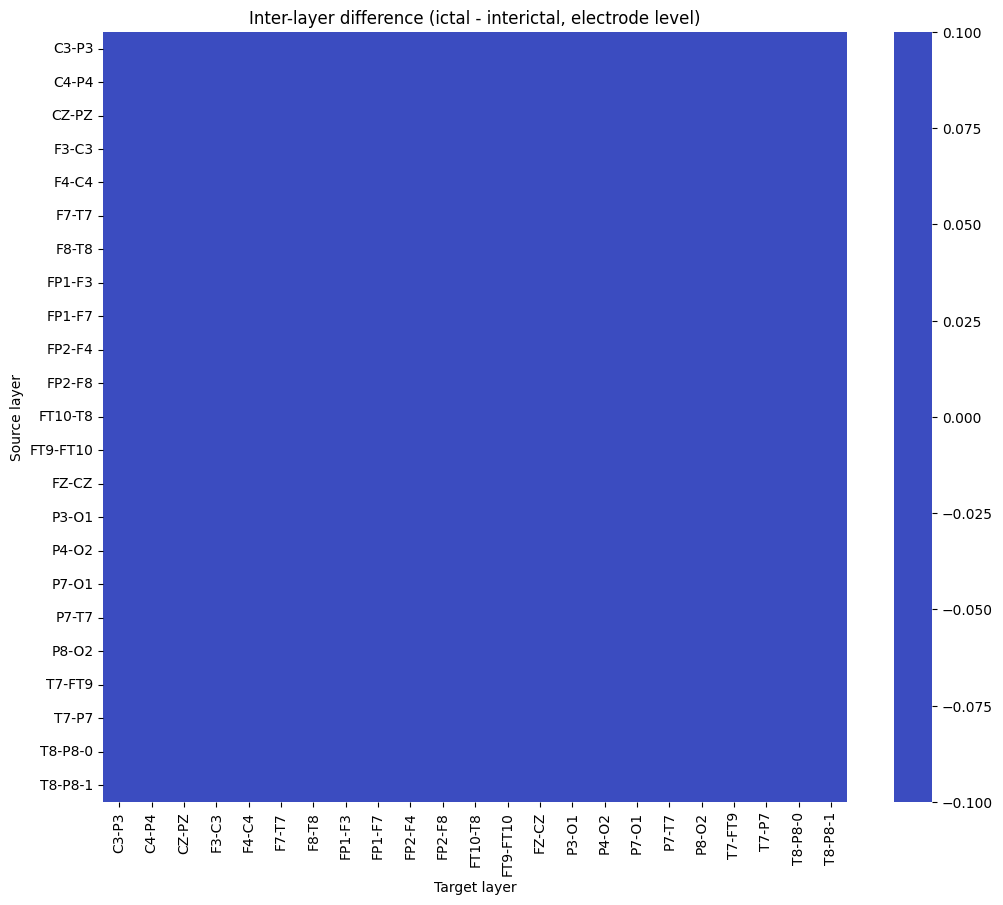

In [20]:
diff_layer_mat = ictal_inter_layer_mat - interictal_inter_layer_mat

plt.figure(figsize=(12, 10))
sns.heatmap(diff_layer_mat, cmap="coolwarm", center=0)
plt.title("Inter-layer difference (ictal - interictal, electrode level)")
plt.xlabel("Target layer")
plt.ylabel("Source layer")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()